In [76]:
from pathlib import Path
import pandas as pd

DATA_DIR = Path("data")

# Auto find train*.csv / test*.csv（compatible train.csv or train (1).csv）
train_path = sorted(DATA_DIR.glob("train*.csv"))[0]
test_path  = sorted(DATA_DIR.glob("test*.csv"))[0]
train_path, test_path
# Reading data
train = pd.read_csv(train_path)
test  = pd.read_csv(test_path)

print("Train shape:", train.shape)
print("Test shape :", test.shape)
train.head()


Train shape: (1460, 81)
Test shape : (1459, 80)


,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500
1,2,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500
2,3,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500
3,4,70,RL,60.0,9550,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml,140000
4,5,60,RL,84.0,14260,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,12,2008,WD,Normal,250000


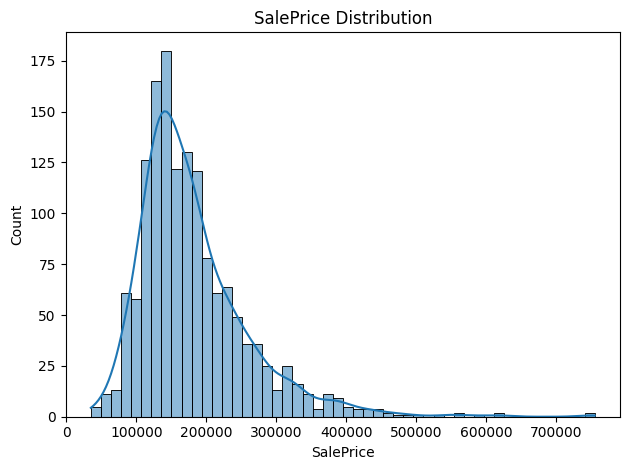

In [77]:
import matplotlib.pyplot as plt
import seaborn as sns
import os

IMG_DIR = "images"
os.makedirs(IMG_DIR, exist_ok=True)

# Missing Values Top 20
missing = train.isnull().sum().sort_values(ascending=False)
missing.head(20)

# (SalePrice)
plt.figure()
sns.histplot(train["SalePrice"], kde=True, bins=50)
plt.title("SalePrice Distribution")
plt.tight_layout()
plt.savefig(f"{IMG_DIR}/target_hist.png")
plt.show()



In [78]:
import numpy as np

num_cols = train.select_dtypes(include=[np.number]).columns.drop(["SalePrice", "Id"])
cat_cols = train.select_dtypes(exclude=[np.number]).columns

print("Numeric features:", len(num_cols))
print("Categorical features:", len(cat_cols))
list(cat_cols)[:10]  # See first 10 list


Numeric features: 36
Categorical features: 43


['MSZoning',
 'Street',
 'Alley',
 'LotShape',
 'LandContour',
 'Utilities',
 'LotConfig',
 'LandSlope',
 'Neighborhood',
 'Condition1']

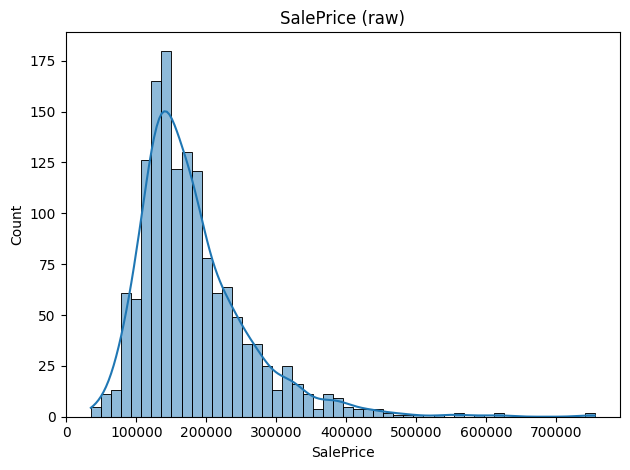

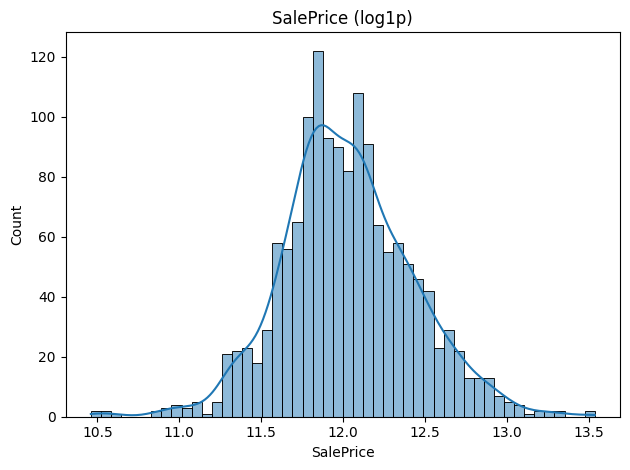

In [ ]:
# === A. Manage target skewness/imbalance：log1p + Percentile stratification + sample weight
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split

# 1) Take the logarithm of the target to alleviate the right deviation
y_log = np.log1p(train["SalePrice"])

# 2) Percentile bucketing ensures that the validation set is also representative in the high_priced tail
price_bins = pd.qcut(train["SalePrice"], q=10, labels=False, duplicates='drop')

# 3) Layered segmentation
X = train.drop(["SalePrice", "Id"], axis=1)
X_train, X_valid, y_train_log, y_valid_log, bins_train, bins_valid = train_test_split(
    X, y_log, price_bins, test_size=0.2, random_state=42, stratify=price_bins
)

# 4) Sample weight, The inverse of the bucket frequency
bin_freq = pd.Series(bins_train).value_counts(normalize=True)
w_train = pd.Series(bins_train).map(lambda b: 1.0 / bin_freq[b]).to_numpy()

# 5) Draw the log distribution before and after to prove that the imbalance is managed
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure()
sns.histplot(train["SalePrice"], kde=True, bins=50)
plt.title("SalePrice (raw)"); plt.tight_layout(); plt.savefig("images/target_hist_raw.png"); plt.show()

plt.figure()
sns.histplot(y_log, kde=True, bins=50)
plt.title("SalePrice (log1p)"); plt.tight_layout(); plt.savefig("images/target_hist_log.png"); plt.show()


Fitting 3 folds for each of 20 candidates, totalling 60 fits
Best RF params: {'regressor__max_depth': 16, 'regressor__max_features': np.float64(0.4063865008880857), 'regressor__min_samples_leaf': 2, 'regressor__min_samples_split': 5, 'regressor__n_estimators': 291}

✅ Tuned Random Forest (with log-target) evaluation:
RMSLE = 0.1249
MAE   = 15,124.01
RMSE  = 25,505.48
R²    = 0.8985


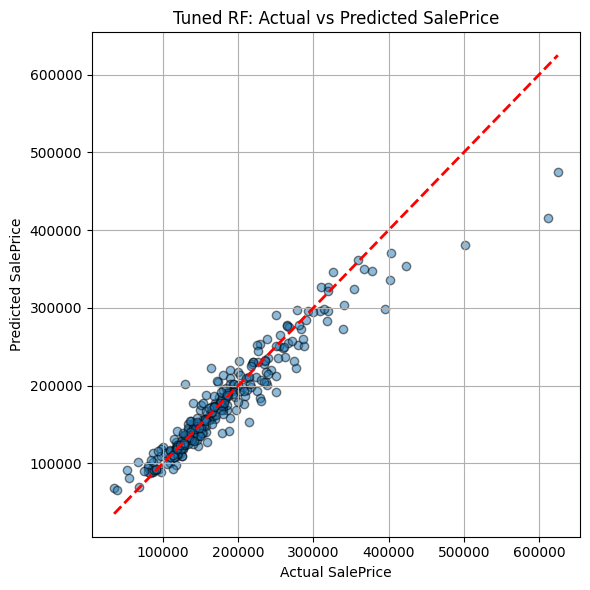

In [ ]:
from sklearn.model_selection import train_test_split, RandomizedSearchCV, KFold
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.ensemble import RandomForestRegressor
from scipy.stats import randint, uniform
from sklearn.metrics import mean_squared_log_error
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
import numpy as np

# --- FAST MODE: First deliver a deliverable parameter adjustment result
param_dist = {
    "regressor__n_estimators": randint(200, 500),
    "regressor__max_depth": randint(8, 28),
    "regressor__max_features": uniform(0.4, 0.4),
    "regressor__min_samples_leaf": randint(1, 5),
    "regressor__min_samples_split": randint(2, 10)
}

cv = KFold(n_splits=3, shuffle=True, random_state=42)

# Avoid double execution：let Search parallel，RF single threaded
rf_pipe = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("regressor", RandomForestRegressor(random_state=42, n_jobs=1)) 
])

search = RandomizedSearchCV(
    rf_pipe,
    param_distributions=param_dist,
    n_iter=20,                     
    cv=cv,
    scoring="neg_root_mean_squared_error",
    n_jobs=-1,                     
    random_state=42,
    verbose=2,                     
    pre_dispatch="2*n_jobs"        
)
# If don't have w_train，remove regressor__sample_weight this parameter
search.fit(X_train, y_train_log, regressor__sample_weight=w_train)

best_rf = search.best_estimator_
print("Best RF params:", search.best_params_)

# Predictions on the validation set（log space -> Inverse transform）
pred_log = best_rf.predict(X_valid)
pred = np.expm1(pred_log)
y_valid_orig = np.expm1(y_valid_log)

rmsle = np.sqrt(mean_squared_log_error(y_valid_orig, pred))
mae   = mean_absolute_error(y_valid_orig, pred)
rmse  = np.sqrt(mean_squared_error(y_valid_orig, pred))
r2    = r2_score(y_valid_orig, pred)

print("\n✅ Tuned Random Forest (with log-target) evaluation:")
print(f"RMSLE = {rmsle:.4f}")
print(f"MAE   = {mae:,.2f}")
print(f"RMSE  = {rmse:,.2f}")
print(f"R²    = {r2:.4f}")

# Scatter plot
plt.figure(figsize=(6,6))
plt.scatter(y_valid_orig, pred, alpha=0.5, edgecolor="k")
plt.plot([y_valid_orig.min(), y_valid_orig.max()],
         [y_valid_orig.min(), y_valid_orig.max()], 'r--', lw=2)
plt.title("Tuned RF: Actual vs Predicted SalePrice")
plt.xlabel("Actual SalePrice"); plt.ylabel("Predicted SalePrice")
plt.grid(True); plt.tight_layout(); plt.savefig("images/actual_vs_pred_rf.png"); plt.show()



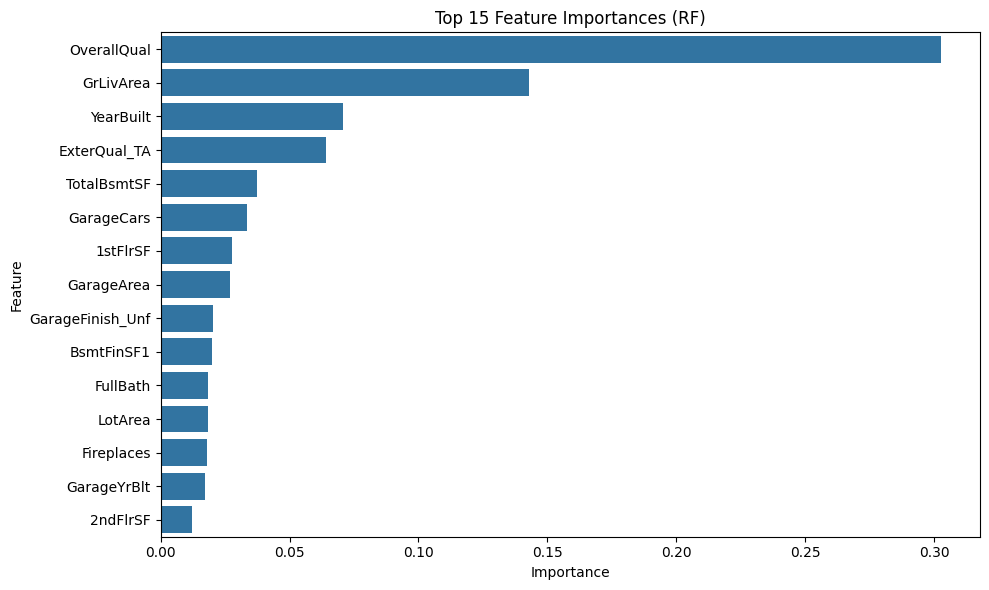

In [ ]:
# === C. Feature Importance（based on best_rf）===
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

importances = best_rf.named_steps["regressor"].feature_importances_

# OneHot Encoded category column name
ohe = best_rf.named_steps["preprocessor"].named_transformers_["cat"].named_steps["encoder"]
cat_features = list(ohe.get_feature_names_out(cat_cols))
all_features = num_cols.tolist() + cat_features

feat_imp = pd.DataFrame({"Feature": all_features, "Importance": importances}) \
            .sort_values("Importance", ascending=False).head(15)

plt.figure(figsize=(10,6))
sns.barplot(x="Importance", y="Feature", data=feat_imp)
plt.title("Top 15 Feature Importances (RF)")
plt.tight_layout(); plt.savefig("images/feature_importance.png"); plt.show()


C:\Users\yenya\AppData\Roaming\Python\Python313\site-packages\keras\src\layers\core\dense.py:92: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step

✅ Deep Learning (dense OHE + log-target) evaluation:
RMSLE = 0.2673
MAE   = 40,634.82
RMSE  = 60,100.94
R²    = 0.4366


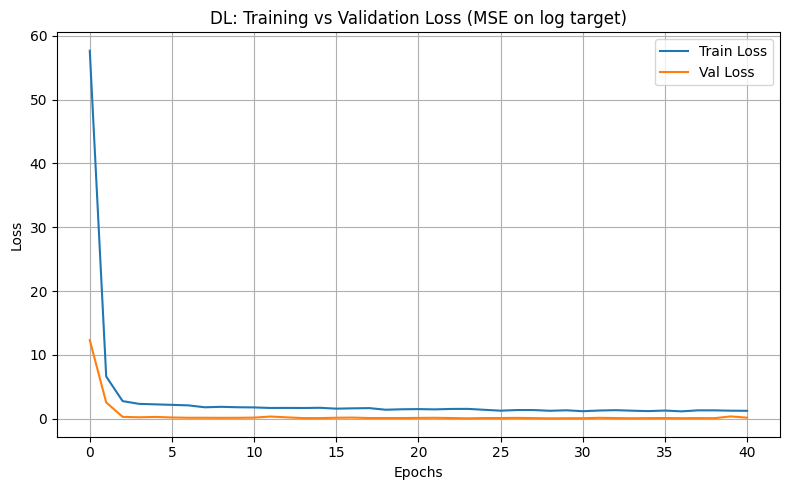

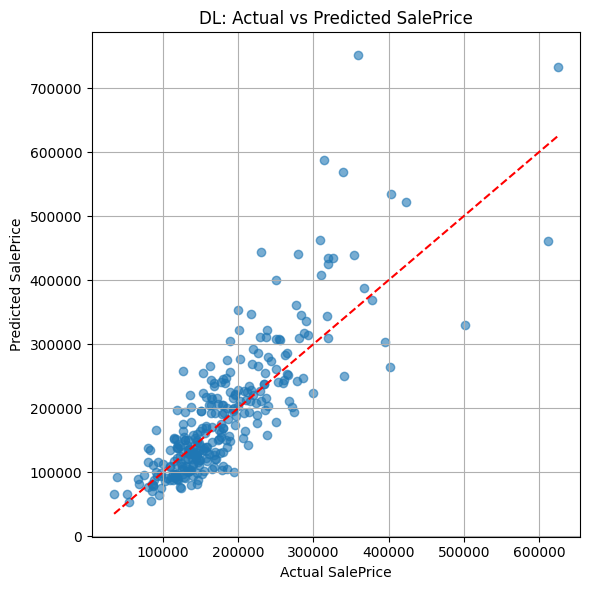

In [ ]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score, mean_squared_log_error
import numpy as np

cat_transformer_dense = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("encoder", OneHotEncoder(handle_unknown="ignore", sparse_output=False))
])
num_transformer_dense = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

preprocessor_dense = ColumnTransformer(
    transformers=[
        ("num", num_transformer_dense, num_cols),
        ("cat", cat_transformer_dense, cat_cols)
    ],
    remainder="drop"
)

X_train_all = preprocessor_dense.fit_transform(X_train)
X_valid_all = preprocessor_dense.transform(X_valid)

y_train_log_arr = y_train_log.to_numpy()
y_valid_log_arr = y_valid_log.to_numpy()

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras import optimizers

model_dl = Sequential([
    Dense(256, activation='relu', input_shape=(X_train_all.shape[1],)),
    Dropout(0.3),
    Dense(128, activation='relu'),
    Dropout(0.2),
    Dense(1)
])

opt = optimizers.Adam(learning_rate=1e-3)
model_dl.compile(optimizer=opt, loss='mse', metrics=['mae'])

es = EarlyStopping(monitor='val_loss', patience=12, restore_best_weights=True)
history = model_dl.fit(
    X_train_all, y_train_log_arr,
    validation_data=(X_valid_all, y_valid_log_arr),
    epochs=200, batch_size=64, callbacks=[es], verbose=0
)

# Inverse transformation to original scale evaluation
pred_log_dl = model_dl.predict(X_valid_all).flatten()
pred_dl = np.expm1(pred_log_dl)
y_valid_orig = np.expm1(y_valid_log_arr)

rmsle_dl = np.sqrt(mean_squared_log_error(y_valid_orig, pred_dl))
mae_dl   = mean_absolute_error(y_valid_orig, pred_dl)
rmse_dl  = np.sqrt(mean_squared_error(y_valid_orig, pred_dl))
r2_dl    = r2_score(y_valid_orig, pred_dl)

print("\n✅ Deep Learning (dense OHE + log-target) evaluation:")
print(f"RMSLE = {rmsle_dl:.4f}")
print(f"MAE   = {mae_dl:,.2f}")
print(f"RMSE  = {rmse_dl:,.2f}")
print(f"R²    = {r2_dl:.4f}")

# Learning curve and scatter plot
plt.figure(figsize=(8,5))
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Val Loss')
plt.title('DL: Training vs Validation Loss (MSE on log target)')
plt.xlabel('Epochs'); plt.ylabel('Loss'); plt.legend(); plt.grid(True); plt.tight_layout(); plt.show()

plt.figure(figsize=(6,6))
plt.scatter(y_valid_orig, pred_dl, alpha=0.6)
plt.plot([y_valid_orig.min(), y_valid_orig.max()],
         [y_valid_orig.min(), y_valid_orig.max()], 'r--')
plt.title("DL: Actual vs Predicted SalePrice")
plt.xlabel("Actual SalePrice"); plt.ylabel("Predicted SalePrice")
plt.grid(True); plt.tight_layout(); plt.show()


In [ ]:
import pandas as pd

# === E. Comparison of the two models (Using the above real result)
comparison = pd.DataFrame({
    'Model': ['Random Forest (tuned)', 'Neural Network (DL, dense OHE)'],
    'Type':  ['Traditional ML',        'Deep Learning'],
    'RMSLE': [rmsle,                   rmsle_dl],
    'MAE':   [mae,                     mae_dl],
    'RMSE':  [rmse,                    rmse_dl],
    'R2':    [r2,                      r2_dl]
})
display(comparison)


,Model,Type,RMSLE,MAE,RMSE,R2
0,Random Forest (tuned),Traditional ML,0.124866,15124.012567,25505.483641,0.898527
1,"Neural Network (DL, dense OHE)",Deep Learning,0.267297,40634.820807,60100.941497,0.436562
